# Lesson 2.1 - Linear Algebra for ML & AI

## Objectives
- Practice vector/matrix operations and shape reasoning.
- Solve linear regression using closed-form and gradient descent.
- Demonstrate embedding similarity retrieval with cosine distance.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)

## Section A - Vectors, Matrices, and Core Operations

In [2]:
a = np.array([1.0, 2.0, 3.0])
b = np.array([4.0, 5.0, 6.0])
A = np.array([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]])

print("a shape:", a.shape)
print("A shape:", A.shape)
print("dot(a,b):", float(a @ b))
print("A^T A:\n", A.T @ A)


a shape: (3,)
A shape: (3, 2)
dot(a,b): 32.0
A^T A:
 [[35. 44.]
 [44. 56.]]


## Section B - Dot Product, Norm, Cosine Similarity

In [3]:
def cosine_similarity(x: np.ndarray, y: np.ndarray) -> float:
    denom = np.linalg.norm(x) * np.linalg.norm(y)
    if denom == 0:
        raise ValueError("Zero vector not allowed for cosine similarity")
    return float((x @ y) / denom)


user_vec = np.array([0.7, 0.2, 0.9, 0.1])
item_a = np.array([0.65, 0.3, 0.85, 0.2])
item_b = np.array([0.1, 0.95, 0.05, 0.8])

print("sim(user, item_a):", round(cosine_similarity(user_vec, item_a), 4))
print("sim(user, item_b):", round(cosine_similarity(user_vec, item_b), 4))

sim(user, item_a): 0.9909
sim(user, item_b): 0.2657


## Section C - Linear Regression in Matrix Form

Closed-form: theta = (X^T X)^(-1) X^T y for invertible X^T X.

In [4]:
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = 3.4 * X.squeeze() + 2.1 + np.random.normal(scale=1.8, size=100)

X_design = np.column_stack([np.ones(X.shape[0]), X.squeeze()])
theta_closed = np.linalg.pinv(X_design.T @ X_design) @ X_design.T @ y
y_hat_closed = X_design @ theta_closed

print("theta_closed:", np.round(theta_closed, 4))

theta_closed: [1.7889 3.4248]


## Section D - Gradient Descent for the Same Problem

In [5]:
def mse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean((y_true - y_pred) ** 2))


def fit_gd(Xm: np.ndarray, yv: np.ndarray, lr: float = 0.01, epochs: int = 3000):
    w = np.zeros(Xm.shape[1])
    losses = []
    n = Xm.shape[0]
    for _ in range(epochs):
        pred = Xm @ w
        err = pred - yv
        grad = (2 / n) * (Xm.T @ err)
        w -= lr * grad
        losses.append(mse(yv, pred))
    return w, losses


theta_gd, losses = fit_gd(X_design, y, lr=0.02, epochs=2500)
y_hat_gd = X_design @ theta_gd
print("theta_gd:", np.round(theta_gd, 4))
print("final_loss:", round(losses[-1], 4))

theta_gd: [1.7889 3.4248]
final_loss: 2.6403


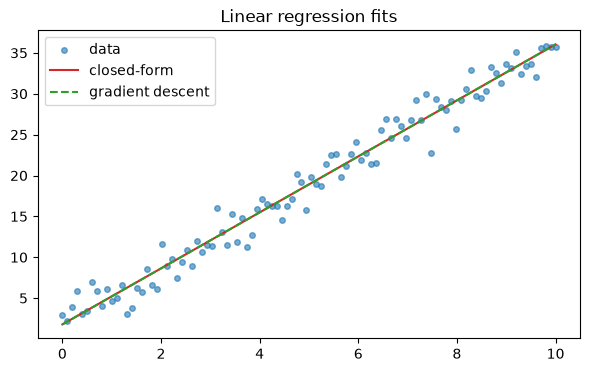

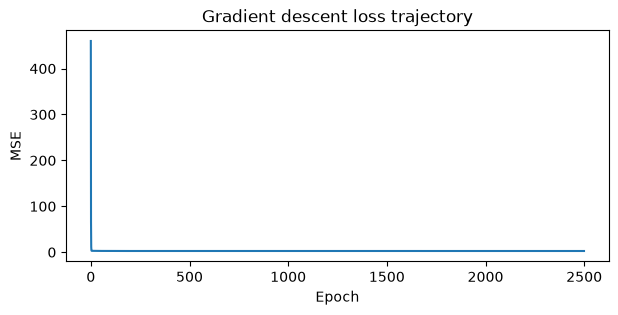

In [6]:
plt.figure(figsize=(7, 4))
plt.scatter(X.squeeze(), y, s=16, alpha=0.6, label="data")
plt.plot(X.squeeze(), y_hat_closed, color="tab:red", label="closed-form")
plt.plot(X.squeeze(), y_hat_gd, color="tab:green", linestyle="--", label="gradient descent")
plt.legend()
plt.title("Linear regression fits")
plt.show()

plt.figure(figsize=(7, 3))
plt.plot(losses)
plt.title("Gradient descent loss trajectory")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

## Section E - Embedding Similarity Demo (Semantic Search Intuition)

In [7]:
docs = np.array(
    [
        [0.7, 0.2, 0.9, 0.1],
        [0.1, 0.9, 0.1, 0.8],
        [0.6, 0.3, 0.8, 0.2],
        [0.2, 0.8, 0.2, 0.7],
    ],
    dtype=float,
)
query = np.array([0.65, 0.25, 0.88, 0.15], dtype=float)

sims = [cosine_similarity(doc, query) for doc in docs]
ranking = np.argsort(sims)[::-1]
print("cosine scores:", [round(s, 4) for s in sims])
print("ranked doc indices:", ranking.tolist())

cosine scores: [0.9973, 0.3628, 0.9962, 0.4906]
ranked doc indices: [0, 2, 3, 1]


## Business Case Studies & Exceptions
- Matrix shape bugs are a common source of silent inference errors.
- Cosine similarity often works well in embedding retrieval, but business constraints may require hybrid lexical + vector matching.

## Interview Questions & Answers
1. Why use pseudo-inverse instead of raw inverse? Better numerical stability on ill-conditioned matrices.
2. Why normalize embeddings? To focus ranking on directional similarity.